<a href="https://colab.research.google.com/github/NicholasAtt/AmazonPrisma/blob/main/notebooks/bertopic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BERTopic: Comprehensive Topic Modeling and Sentiment Analysis

This notebook demonstrates an advanced workflow for topic modeling using BERTopic. It starts with raw text data, enriches it using Named Entity Recognition (NER) and TAGME (a topic annotation tool), and then applies BERTopic to discover topics.

The analysis is further extended to include:
- **Polarity Analysis**: Identifying the sentiment (positive/negative) associated with each topic.
- **Emotion Analysis**: Determining the dominant emotions within the most positive and negative topics.
- **Aspect-Based Sentiment Analysis (ABSA)**: Pinpointing specific product features (e.g., 'price', 'battery') and their associated sentiment within reviews.

## 1. Setup and Installation

This section installs all the necessary Python libraries for the project. We use `pip` to install libraries for data manipulation, deep learning, NLP, and topic modeling.

In [ ]:
print("Installing necessary libraries...")
!pip install pandas torch transformers spacy sentence-transformers --quiet
!pip install tagme --quiet
!pip install bertopic --quiet
!pip install umap-learn hdbscan scikit-learn plotly --quiet
!python -m spacy download en_core_web_sm --quiet
!pip install pydrive2


print("Libraries installed successfully.")

Installing necessary libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 70.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Libraries installed successfully.


## 2. Importing Libraries

Here, we import all the required modules and packages that will be used throughout the notebook.

In [ ]:
# Standard and Data Handling Libraries
import pandas as pd
import numpy as np
import re
import time
import warnings
import torch
import getpass

# NLP and Topic Modeling Libraries
import tagme
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, CountVectorizer

# Google Colab Integration (for data loading)
from google.colab import auth, drive
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from oauth2client.client import GoogleCredentials

## 3. Configuration and Data Loading

We set up global configurations, authenticate with Google Drive to access the dataset, and load the data into a Pandas DataFrame. We then take a smaller sample for efficient processing.

In [ ]:
# --- Configurations ---
warnings.filterwarnings('ignore')
pd.options.display.max_colwidth = 200

# --- Google Drive Authentication and File Loading ---
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive_service = GoogleDrive(gauth)

# Load the training data from Google Drive
id_train = '1kddgLOIVkn5HJw8Ib6rrUh5RkcMwsWeM'
file1 = drive_service.CreateFile({'id': id_train})
file1.GetContentFile('train.csv.gz')
df_train = pd.read_csv('train.csv.gz', header=None, names=['polarity', 'title', 'text'])

# --- Data Sampling ---
SAMPLE_SIZE = 10000
df = df_train.sample(n=SAMPLE_SIZE, random_state=42)
print(f"Data loaded and sampled. Working with {len(df)} records.")

Data loaded and sampled. Working with 10000 records.


## 4. Text Preprocessing

This section contains a function to clean the text data. It removes extra whitespace and combines the 'title' and 'text' fields into a single column `original_text`. We also filter out very short texts that are unlikely to be useful.

In [ ]:
def preprocess_text(text):
    """Cleans text by removing extra whitespace."""
    if not isinstance(text, str):
        return ""
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text.strip())
    return text

# Apply preprocessing
df['text'] = df['text'].apply(preprocess_text)
df['title'] = df['title'].apply(preprocess_text)

# Combine title and text for a complete context
df['original_text'] = df['title'] + ". " + df['text']

# Filter out very short texts
df = df[df['original_text'].str.len() > 20].reset_index(drop=True)
print(f"Records remaining after cleaning: {len(df)}")

Records remaining after cleaning: 10000


## 5. Loading AI Models and API Setup

We load the pre-trained NER (Named Entity Recognition) model from Hugging Face. Additionally, we configure the TAGME API, which requires a personal API token for entity linking.

In [ ]:
print("\nLoading AI Models and setting up API...")

# Load NER model from Hugging Face
print("Loading NER model...")
ner_pipeline = pipeline(
    "ner",
    model="dbmdz/bert-large-cased-finetuned-conll03-english",
    aggregation_strategy="simple",
    device=0 if torch.cuda.is_available() else -1
)
print("NER model loaded.")

# Configure TAGME API
print("\nConfiguring TAGME API...")
TAGME_API_TOKEN = getpass.getpass("Please enter your TAGME API token: ")
tagme.GCUBE_TOKEN = TAGME_API_TOKEN
print("TAGME API configured.")

## 6. Text Enrichment Functions

This block contains all the helper functions for our hybrid text enrichment pipeline. These functions are designed to:
1.  **Extract Named Entities (NER)**: Identify persons, organizations, products, etc.
2.  **Extract TAGME Entities**: Link text mentions to Wikipedia pages for disambiguation.
3.  **Clean Text for BERTopic**: Remove noise and formatting that can interfere with topic modeling.
4.  **Contextually Enrich Text**: Intelligently combine the original text with the entities found by NER and TAGME to create a more informative input for BERTopic.

In [ ]:
def extract_entities_ner_with_positions(texts_list, ner_model):
    """Extracts named entities with their start/end positions using the NER model."""
    all_entities_with_pos = []
    # Focus on labels relevant for product/service topic modeling
    relevant_labels = {'PERSON', 'ORG', 'PRODUCT', 'EVENT', 'LOC'}

    try:
        results = ner_model(texts_list)

        for i, doc_entities in enumerate(results):
            entities_info = []
            current_text = texts_list[i]
            used_positions = set()

            for entity in doc_entities:
                if (entity['entity_group'] in relevant_labels and not entity['word'].startswith('##')):
                    word = entity['word'].replace('##', '').strip()

                    # Filter out very short or generic words
                    if len(word) < 3:
                        continue

                    # Filter out common words that don't add semantic value
                    common_words_ner = {'you', 'it', 'the', 'this', 'that', 'they', 'them'}
                    if word.lower() in common_words_ner:
                        continue

                    # Find the exact position in the text to avoid duplicates
                    text_lower = current_text.lower()
                    word_lower = word.lower()
                    start_idx = 0

                    while start_idx < len(text_lower):
                        pos = text_lower.find(word_lower, start_idx)
                        if pos == -1:
                            break

                        is_word_boundary = (
                            (pos == 0 or not text_lower[pos-1].isalnum()) and
                            (pos + len(word_lower) >= len(text_lower) or not text_lower[pos + len(word_lower)].isalnum())
                        )

                        if is_word_boundary and pos not in used_positions:
                            entities_info.append({
                                'word': current_text[pos:pos+len(word)],
                                'start': pos,
                                'end': pos + len(word),
                                'label': entity['entity_group']
                            })
                            used_positions.add(pos)
                            break
                        start_idx = pos + 1
            all_entities_with_pos.append(entities_info)
        return all_entities_with_pos
    except Exception as e:
        print(f"Error during NER extraction with positions: {e}")
        return [[] for _ in texts_list] # Return empty list on failure

def extract_tagme_with_positions(text):
    """Extracts and filters TAGME entities, returning them with positions."""
    try:
        annotations = tagme.annotate(text, lang='en')
        tagme_entities = []

        # Patterns to exclude (often noise for product reviews)
        exclude_patterns = [
            'song', 'album', 'single', 'band', 'music', 'film', 'movie', 'tv',
            'actor', 'actress', 'singer', 'musician', 'character', 'fictional'
        ]
        common_words = {
            'you', 'it', 'the', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
            'with', 'by', 'from', 'up', 'about', 'into', 'through', 'during',
            'white', 'black', 'red', 'blue', 'green', 'yellow', 'color', 'colours'
        }

        for ann in annotations.get_annotations(0.15):  # Quality threshold
            mention_lower = ann.mention.lower()
            title_lower = ann.entity_title.lower()

            if mention_lower in common_words or len(ann.mention) < 3:
                continue

            if any(pattern in title_lower for pattern in exclude_patterns):
                continue

            if mention_lower == title_lower:
                continue

            if ann.score > 0.15:
                tagme_entities.append({
                    'word': ann.mention,
                    'start': ann.begin,
                    'end': ann.end,
                    'wiki_title': ann.entity_title,
                    'score': ann.score
                })
        return tagme_entities
    except Exception as e:
        print(f"⚠️ Warning: TAGME API call failed. Error: {e}")
        return []

def clean_text_for_bertopic(text):
    """Cleans text by removing characters and patterns that are problematic for BERTopic."""
    text = re.sub(r'\([^)]*\)', '', text)  # Remove content in parentheses
    text = re.sub(r'\[[^\]]*\]', '', text) # Remove content in square brackets
    text = re.sub(r'\{[^}]*\}', '', text) # Remove content in curly brackets
    text = re.sub(r'\s+', ' ', text)      # Normalize whitespace
    text = text.strip()
    text = re.sub(r'\.{2,}', '.', text)     # Remove multiple dots
    text = re.sub(r'[,\.][\s]*[,\.]', '.', text) # Clean up double commas/dots
    return text

def remove_overlapping_replacements(replacements):
    """Removes overlapping replacements, giving priority to TAGME."""
    if not replacements:
        return []

    sorted_replacements = sorted(replacements, key=lambda x: x['start'])
    filtered = []
    if not sorted_replacements:
        return []

    # Add the first replacement to the list
    filtered.append(sorted_replacements[0])

    for current in sorted_replacements[1:]:
        previous = filtered[-1]
        # Check for overlap
        if current['start'] < previous['end']:
            # Overlap exists. Prioritize TAGME.
            if current['type'] == 'TAGME' and previous['type'].startswith('NER'):
                # Replace the previous NER entity with the current TAGME one
                filtered[-1] = current
            # Otherwise, keep the previous one and discard the current one
        else:
            # No overlap, add the current replacement
            filtered.append(current)
    return filtered

def enrich_text_contextually(text, ner_entities, tagme_entities):
    """Inserts NER and TAGME entities into the text to provide context for BERTopic."""
    replacements = []

    # Add replacements for TAGME entities
    for entity in tagme_entities:
        wiki_title = entity['wiki_title'].replace('_', ' ')
        wiki_title_clean = re.sub(r'\([^)]*\)', '', wiki_title).strip()
        if (entity['word'].lower() != wiki_title_clean.lower() and len(wiki_title_clean) > len(entity['word']) and wiki_title_clean):
            replacements.append({
                'start': entity['start'], 'end': entity['end'], 'original': entity['word'],
                'replacement': f"{entity['word']} {wiki_title_clean}", 'type': 'TAGME'
            })

    # Add replacements for NER entities
    for entity in ner_entities:
        if entity['label'] == 'PRODUCT':
            replacements.append({
                'start': entity['start'], 'end': entity['end'], 'original': entity['word'],
                'replacement': f"{entity['word']} product", 'type': 'NER_PRODUCT'
            })
        elif entity['label'] == 'ORG':
            replacements.append({
                'start': entity['start'], 'end': entity['end'], 'original': entity['word'],
                'replacement': f"{entity['word']} company", 'type': 'NER_ORG'
            })

    # Remove overlaps, prioritizing TAGME
    replacements = remove_overlapping_replacements(replacements)

    # Apply replacements in reverse order to not mess up indices
    replacements.sort(key=lambda x: x['start'], reverse=True)
    enriched_text = text
    for repl in replacements:
        start, end = repl['start'], repl['end']
        if 0 <= start < len(enriched_text) and 0 <= end <= len(enriched_text):
            enriched_text = enriched_text[:start] + repl['replacement'] + enriched_text[end:]

    # Final cleanup
    return clean_text_for_bertopic(enriched_text)

## 7. Applying Text Enrichment

This is the main processing step. We iterate through each document in our dataset, apply the NER and TAGME extraction functions, and then use the `enrich_text_contextually` function to create the final, enriched text.

**Note**: This process can be time-consuming (~1-2 hours for 10,000 documents) as it involves making API calls and running large models.

In [ ]:
enriched_texts = []
texts_to_process = df['original_text'].tolist()

print("Running NER in batches with positions...")
# Process NER in one batch for efficiency
ner_results = extract_entities_ner_with_positions(texts_to_process, ner_pipeline)

print("Running TAGME and contextual enrichment for each document...")
for i, text in enumerate(texts_to_process):
    # Get pre-computed NER entities
    ner_entities = ner_results[i]

    # Get TAGME entities (API call per document)
    tagme_entities = extract_tagme_with_positions(text)

    # Perform contextual enrichment
    enriched_text = enrich_text_contextually(text, ner_entities, tagme_entities)
    enriched_texts.append(enriched_text)

    # Print progress
    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(texts_to_process)} texts")

# Add the new enriched text column to the DataFrame
df['enriched_text'] = enriched_texts
print("\nContextual text enrichment completed.")

print("\nExample of original vs. enriched text:")
for i in range(min(3, len(df))):
    print(f"\n--- EXAMPLE {i+1} ---")
    print(f"ORIGINAL: {df.iloc[i]['original_text'][:250]}...")
    print(f"ENRICHED: {df.iloc[i]['enriched_text'][:300]}...")

## 8. BERTopic Model Training

Now that we have our enriched text, we can proceed with the topic modeling. This section covers:
1.  **Embedding Generation**: Converting the text documents into numerical vectors using a `sentence-transformer` model.
2.  **BERTopic Initialization**: Setting up the BERTopic model with our chosen embedding model.
3.  **Model Fitting**: Training the model on the document embeddings to discover topics.
4.  **Outlier Reduction**: Re-assigning documents that were not initially clustered into a topic (outliers) to the most similar existing topic.

In [ ]:
# Use the enriched text column for topic modeling
docs = df['enriched_text'].tolist()

# 1. Select the embedding model
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Create document embeddings
print("Creating document embeddings...")
embeddings = embedding_model.encode(docs, show_progress_bar=True)

# 3. Initialize the BERTopic model
topic_model = BERTopic(
    embedding_model=embedding_model,
    verbose=True,
    min_topic_size=10  # Merge smaller topics
)

# 4. Train the model
print("\nTraining the BERTopic model...")
start_time = time.time()
topics, probs = topic_model.fit_transform(docs, embeddings)
end_time = time.time()
print(f"Model training finished in {end_time - start_time:.2f} seconds.")

# Check initial number of outliers (Topic -1)
print(f"\nInitial number of outliers (Topic -1): {np.sum(np.array(topics) == -1)}")

# 5. Reduce outliers
print("Attempting to reduce outliers...")
new_topics = topic_model.reduce_outliers(docs, topics, strategy="embeddings")
print(f"New number of outliers: {np.sum(np.array(new_topics) == -1)}")

## 9. Topic Representation Refinement

To improve the quality and interpretability of the topics, we define a list of custom stopwords to remove generic and uninformative words (e.g., 'product', 'amazon', 'good'). We then update the topic representations using this refined vocabulary.

In [ ]:
# Define custom stopwords to clean up topic representations
custom_stopwords = list(ENGLISH_STOP_WORDS.union([
    'the', 'to', 'of', 'in', 'it', 'for', 'is', 'this',
    'on', 'my', 'product', 'item', 'thing', 'stuff',
    'amazon', 'buy', 'purchase', 'bought', 'order', 'shipping', 'delivery',
    'use', 'used', 'using',
    'get', 'got', 'one', 'also', 'even', 'really',
    'work', 'works', 'working', 'well', 'perfect',
    'recommend', 'highly', 'love', 'like', 'good', 'great', 'nice',
    'bad', 'poor', 'waste', 'disappointed', 'okay',
    'quality', 'price', 'value', 'money', 'deal',
    'review', 'reviews', 'star', 'stars',
    'would', 'could', 'should',
    'received', 'came', 'arrived', 'time', 'day', 'week',
    'return', 'returned', 'replace', 'replacement',
    'thank', 'thanks', 'ner', 'org', 'misc', 'just'
]))

# Create a new vectorizer with the custom stopwords
vectorizer_clean = CountVectorizer(ngram_range=(1, 2), stop_words=custom_stopwords)

# Update the topic representations
topic_model.update_topics(docs, vectorizer_model=vectorizer_clean, topics=new_topics)

# Save the final topic assignments to the DataFrame
df['topic'] = new_topics

print("Topics have been refined with custom stopwords.")

## 10. Initial Topic Analysis and Visualization

Let's get a first look at the topics we've found. We'll print a summary table of all topics and their keywords. Then, we will generate an interactive 2D plot that shows the topics as clusters of documents.

In [ ]:
print("\n--- Analysis of Discovered Topics ---")

# Get a summary of the topics
topic_info = topic_model.get_topic_info()
print("\nGeneral Topic Information:")
print(topic_info.to_string())

# Show keywords for the first topic (after the outlier topic -1)
if len(topic_info) > 1:
    first_topic_id = topic_info.iloc[1]['Topic']
    print(f"\n--- Details for Topic #{first_topic_id} ---")
    print(topic_model.get_topic(first_topic_id))

print("\nGenerating interactive topic visualization...")
try:
    # This creates an interactive plot of the topics
    fig = topic_model.visualize_topics()
    fig.show()
except Exception as e:
    print(f"Could not generate visualization: {e}")

## 11. Polarity Analysis by Topic

Here, we analyze the sentiment within each topic. We calculate a `Net_Sentiment_Score` for each topic, which ranges from -1 (entirely negative reviews) to +1 (entirely positive reviews). This allows us to quickly identify topics associated with customer complaints versus topics associated with praise.

In [ ]:
print("\n--- Polarity Analysis by Topic ---")

# Map numeric polarity to human-readable labels
df['sentiment_label'] = df['polarity'].apply(lambda x: 'Positive' if x == 2 else 'Negative')

if 'topic' in df.columns:
    # Group by topic and sentiment to count reviews
    sentiment_distribution = df.groupby(['topic', 'sentiment_label']).size().unstack(fill_value=0)
    sentiment_distribution['Total_Reviews'] = sentiment_distribution.sum(axis=1)

    # Ensure both sentiment columns exist
    if 'Positive' not in sentiment_distribution: sentiment_distribution['Positive'] = 0
    if 'Negative' not in sentiment_distribution: sentiment_distribution['Negative'] = 0

    # Calculate a Net Sentiment Score: (Positive - Negative) / Total
    sentiment_distribution['Net_Sentiment_Score'] = \
        (sentiment_distribution['Positive'] - sentiment_distribution['Negative']) / sentiment_distribution['Total_Reviews']

    # Merge with topic info for a complete analysis table
    topic_info = topic_model.get_topic_info()
    full_topic_analysis = topic_info.merge(sentiment_distribution, left_on='Topic', right_index=True)
    full_topic_analysis = full_topic_analysis.sort_values(by='Net_Sentiment_Score', ascending=True)

    print("\n--- Polarity Analysis for Each Topic ---")
    print("(Sorted from most negative to most positive)")
    print(full_topic_analysis[['Topic', 'Count', 'Name', 'Negative', 'Positive', 'Net_Sentiment_Score']].to_string())


--- Polarity Analysis by Topic ---

--- Polarity Analysis for Each Topic ---
(Sorted from most negative to most positive)
    Topic  Count                                              Name  Negative  Positive  Net_Sentiment_Score
74     74     46                      74_refund_seller_company_com        43         3            -0.869565
65     65     26                       65_screen_monitor_stylus_tv        24         2            -0.846154
61     61     36                       61_game_computer_games_play        32         4            -0.777778
9       9     98                      9_dvd_player_disc_dvd player        85        13            -0.734694
63     63     50                   63_packaging_box_bottles_broken        42         8            -0.680000
43     43     68                      43_months_worked_heater_heat        57        11            -0.676471
12     12    133                           12_worked_don_junk_unit       111        22            -0.669173
67     67    

## 12. Visualization of Topic Polarity

This chart visualizes the sentiment distribution for the most polarized topics (the top most positive and top most negative). It helps to quickly see which topics are overwhelmingly positive or negative.


Generating chart for polarity distribution...


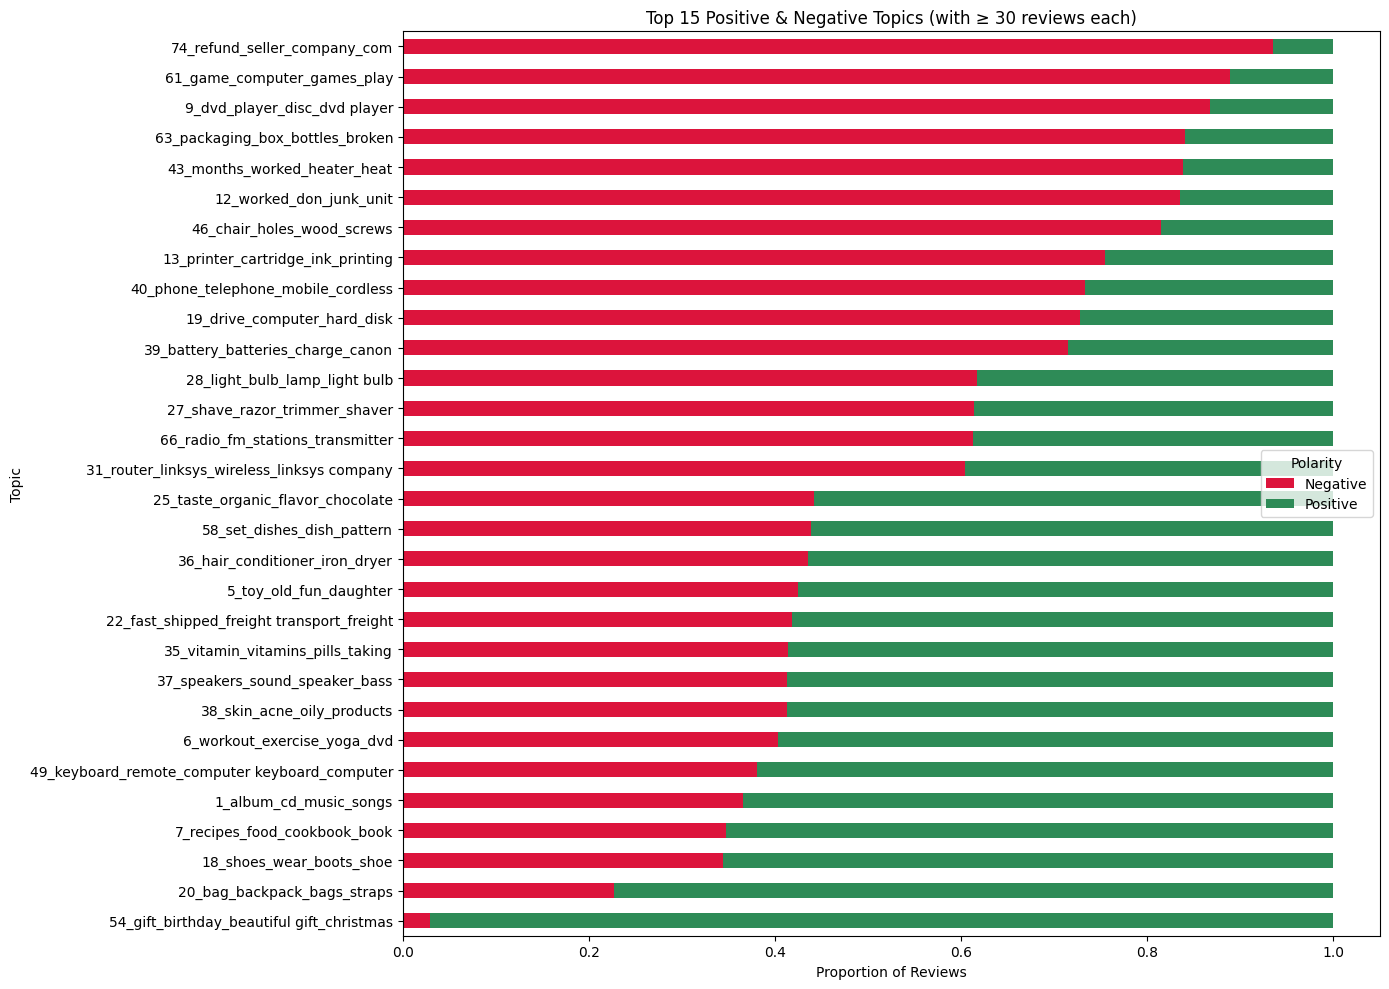

In [ ]:
print("\nGenerating chart for polarity distribution...")
try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    plot_data = full_topic_analysis[full_topic_analysis['Topic'] != -1].set_index('Name')

    # Filter: consider only topics with a minimum number of reviews
    min_reviews = 30
    filtered_data = plot_data[plot_data['Total_Reviews'] >= min_reviews]

    # Select top 15 negative and top 15 positive from the filtered ones
    bottom_15 = filtered_data.nsmallest(15, 'Net_Sentiment_Score')
    top_15 = filtered_data.nlargest(15, 'Net_Sentiment_Score')
    plot_data_filtered = pd.concat([bottom_15, top_15])

    # Calculate proportions for stacking
    plot_data_proportions = plot_data_filtered[['Negative', 'Positive']].div(plot_data_filtered['Total_Reviews'], axis=0)

    # Sort for a clean visualization from negative to positive
    plot_data_proportions = plot_data_proportions.loc[
        plot_data_filtered.sort_values('Net_Sentiment_Score', ascending=True).index
    ]

    # Create the stacked bar chart
    plot_data_proportions.plot(
        kind='barh',
        stacked=True,
        color={'Positive': 'seagreen', 'Negative': 'crimson'},
        figsize=(14, 10),
        title=f'Top 15 Positive & Negative Topics (with ≥ {min_reviews} reviews each)'
    )

    plt.xlabel('Proportion of Reviews')
    plt.ylabel('Topic')
    plt.legend(title='Polarity')
    plt.tight_layout()
    plt.gca().invert_yaxis()
    plt.show()

except Exception as e:
    print(f"Error during chart generation: {e}")

## 13. Additional BERTopic Visualizations

BERTopic offers a rich set of built-in visualizations to explore the results from different angles. Here we generate:
- **Heatmap**: Shows the similarity between topics.
- **Document Plot**: Visualizes individual documents in the 2D space.
- **Barchart**: A classic bar chart showing the top keywords for each topic.
- **Hierarchy**: A dendrogram showing how topics can be merged hierarchically.

In [ ]:
print("Generating Topic Similarity Heatmap...")
# The similarity matrix shows how similar each topic is to the others
topic_model.visualize_heatmap()


Generating Topic Similarity Heatmap...


In [ ]:
print("\nGenerating Document Visualization Plot...")
from umap import UMAP

# We need to reduce embeddings to 2D for plotting
reduced_embeddings = UMAP(n_neighbors=15, n_components=2, min_dist=0.0, metric='cosine', random_state=42).fit_transform(embeddings)
topic_model.visualize_documents(docs, reduced_embeddings=reduced_embeddings)


Generating Document Visualization Plot...


In [ ]:
print("\nGenerating Topic Keyword Barchart...")
topic_model.visualize_barchart(top_n_topics=12)


Generating Topic Keyword Barchart...


In [ ]:
print("\nGenerating Hierarchical Clustering Visualization...")
topic_model.visualize_hierarchy(top_n_topics=20)


Generating Hierarchical Clustering Visualization...


## 14. Emotion Analysis

Going beyond simple positive/negative sentiment, we now analyze the specific emotions (like joy, sadness, anger) present in the most polarized topics. We use another pre-trained Hugging Face model to classify the emotion of each review and then aggregate the results for our top positive and top negative topics.

In [ ]:
print("Setting up emotion analysis pipeline...")
from collections import Counter

# Load the emotion classification model
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    return_all_scores=True
)

def get_dominant_emotion(text):
    """Classifies the text and returns the emotion with the highest score."""
    if not text or not isinstance(text, str):
        return "unknown"
    try:
        # Truncate text to model's max length
        scores = emotion_classifier(text[:512])[0]
        dominant_emotion = max(scores, key=lambda x: x['score'])
        return dominant_emotion['label']
    except Exception:
        return "error"

print("Applying emotion classification model to all reviews...")
# This can take a while
df['emotion'] = df['original_text'].apply(get_dominant_emotion)
print("Emotion analysis complete.")

# Identify top 5 most negative and positive topics
top_negative_topics = full_topic_analysis.sort_values(
    by=['Net_Sentiment_Score', 'Count'],
    ascending=[True, False]
).head(5)['Topic'].tolist()

top_positive_topics = full_topic_analysis.sort_values(
    by=['Net_Sentiment_Score', 'Count'],
    ascending=[False, False]
).head(5)['Topic'].tolist()

def show_emotions_for_topics(topics, label):
    """Prints the emotion distribution for a given list of topic IDs."""
    print(f"\n--- {label} - Dominant Emotions ---")
    for topic_id in topics:
        subset = df[df['topic'] == topic_id]
        emotions = subset['emotion'].value_counts()
        topic_name = full_topic_analysis[full_topic_analysis['Topic'] == topic_id]['Name'].values[0]

        print(f"\nTopic {topic_id}: {topic_name}")
        print(" Most common emotions:")
        for emotion, count in emotions.head(3).items():
            print(f"   - {emotion}: {count} reviews")

# Display the results
show_emotions_for_topics(top_negative_topics, "Top 5 Negative Topics")
show_emotions_for_topics(top_positive_topics, "Top 5 Positive Topics")

Setting up emotion analysis pipeline...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cuda:0


Applying emotion classification model to all reviews...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Emotion analysis complete.

--- Top 5 Negative Topics - Dominant Emotions ---

Topic 74: 74_refund_seller_company_com
 Most common emotions:
   - sadness: 16 reviews
   - neutral: 12 reviews
   - surprise: 7 reviews

Topic 65: 65_screen_monitor_stylus_tv
 Most common emotions:
   - neutral: 9 reviews
   - disgust: 6 reviews
   - sadness: 4 reviews

Topic 61: 61_game_computer_games_play
 Most common emotions:
   - neutral: 13 reviews
   - disgust: 8 reviews
   - sadness: 8 reviews

Topic 9: 9_dvd_player_disc_dvd player
 Most common emotions:
   - neutral: 34 reviews
   - sadness: 30 reviews
   - disgust: 13 reviews

Topic 63: 63_packaging_box_bottles_broken
 Most common emotions:
   - neutral: 16 reviews
   - surprise: 11 reviews
   - disgust: 10 reviews

--- Top 5 Positive Topics - Dominant Emotions ---

Topic 54: 54_gift_birthday_beautiful gift_christmas
 Most common emotions:
   - joy: 28 reviews
   - neutral: 5 reviews
   - surprise: 1 reviews

Topic 72: 72_blade_vampire_vampires_bl

## 15. Aspect-Based Sentiment Analysis (ABSA)

Finally, we perform ABSA to get the most granular insights. This technique identifies specific features or aspects of a product (e.g., "battery", "screen", "price") mentioned in a review and determines the sentiment towards that specific aspect. We use a zero-shot classification model to achieve this without needing aspect-specific training data.


--- Aspect-Based Sentiment Analysis (ABSA) ---


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Applying ABSA model to a sample of reviews (this may take a few minutes)...
ABSA analysis completed.

--- Sentiment Summary by Aspect within Topics ---
sentiment       negative  positive
topic aspect                      
0     battery         91        58
      design         124       121
      price          115        83
      quality        148       153
      screen         114       103
      shipping       131       119
      sound          162       121
1     battery         33        24
      design          42        60
      price           43        44
      quality         52        74
      screen          44        57
      shipping        49        67
      sound           56        64
2     battery         33        16
      design          62        38
      price           69        31
      quality         68        50
      screen          62        51
      shipping        64        45
      sound           78        40
3     battery          4         2
      de

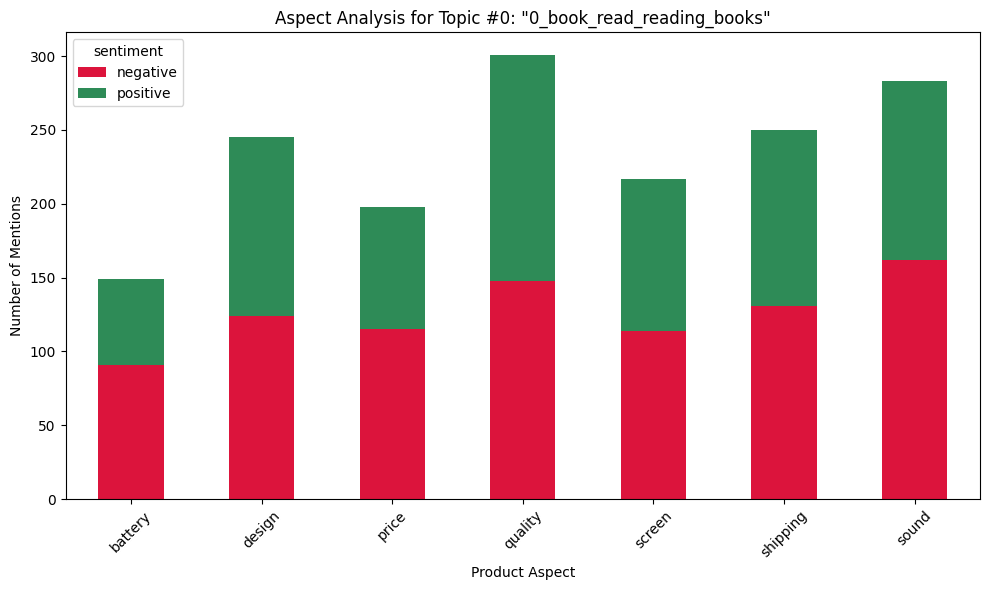

In [ ]:
print("\n--- Aspect-Based Sentiment Analysis (ABSA) ---")

try:
    # Initialize a zero-shot classification pipeline for ABSA
    absa_classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=0 if torch.cuda.is_available() else -1)

    # Define the aspects we are interested in
    aspects = ["price", "quality", "battery", "sound", "screen", "design", "shipping"]

    # Create candidate labels for the zero-shot model
    candidate_labels = []
    for aspect in aspects:
        candidate_labels.append(f"{aspect} positive")
        candidate_labels.append(f"{aspect} negative")

    def analyze_review_aspects(text, threshold=0.6):
        """Analyzes text to find aspects and their sentiment."""
        if not text or not isinstance(text, str):
            return {}

        results = absa_classifier(text[:512], candidate_labels=candidate_labels, multi_label=True)

        found_aspects = {}
        for label, score in zip(results['labels'], results['scores']):
            if score > threshold:
                parts = label.split()
                aspect, sentiment = parts[0], parts[1]
                # Keep only the highest-scoring sentiment for each aspect
                if aspect not in found_aspects or score > found_aspects[aspect]['score']:
                    found_aspects[aspect] = {'sentiment': sentiment, 'score': score}

        return {k: v['sentiment'] for k, v in found_aspects.items()}

    print("Applying ABSA model to a sample of reviews (this may take a few minutes)...")
    # Running on a smaller sample (1000 reviews) for speed
    df['aspects_sentiment'] = df['original_text'].head(1000).apply(analyze_review_aspects)
    print("ABSA analysis completed.")

    # Process the results for analysis
    df_aspects = df.dropna(subset=['aspects_sentiment'])
    df_aspects = df_aspects[df_aspects['aspects_sentiment'] != {}]

    if not df_aspects.empty:
        aspect_rows = []
        for index, row in df_aspects.iterrows():
            for aspect, sentiment in row['aspects_sentiment'].items():
                aspect_rows.append([row['topic'], aspect, sentiment])

        df_exploded_aspects = pd.DataFrame(aspect_rows, columns=['topic', 'aspect', 'sentiment'])

        # Group data to create a summary table
        absa_summary = df_exploded_aspects.groupby(['topic', 'aspect', 'sentiment']).size().unstack(fill_value=0)
        print("\n--- Sentiment Summary by Aspect within Topics ---")
        print(absa_summary.to_string())

        # Visualize aspects for a specific topic
        topic_to_visualize = full_topic_analysis.nlargest(1, 'Count')['Topic'].iloc[0] # Visualize the largest topic
        if topic_to_visualize in absa_summary.index.get_level_values('topic'):
            topic_name = full_topic_analysis[full_topic_analysis['Topic'] == topic_to_visualize]['Name'].values[0]
            absa_summary.loc[topic_to_visualize].plot(
                kind='bar',
                stacked=True,
                color={'positive': 'seagreen', 'negative': 'crimson'},
                figsize=(10, 6),
                title=f'Aspect Analysis for Topic #{topic_to_visualize}: "{topic_name}"'
            )
            plt.ylabel("Number of Mentions")
            plt.xlabel("Product Aspect")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print(f"\nNo aspects found for Topic #{topic_to_visualize} in the analyzed sample.")

    else:
        print("\nNo aspects were detected with the current threshold in the analyzed sample.")

except Exception as e:
    print(f"An error occurred during ABSA: {e}")